<a href="https://colab.research.google.com/github/sonjoy1s/Deep-Learning/blob/main/DL_Assignment_03_Question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# DL Assignment 03

**Name:**

**Course Email:**  


## End of Assignment

Before submitting:
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# General Instruction

You must choose your own dataset.

The dataset must:

Be a supervised learning dataset (Regression or Binary Classification)

Contain at least 300 samples

Have at least 2 input features

Be in CSV format

You are NOT allowed to use Dataset or DataLoader.

You must implement everything manually.

# Question 01: [ Marks 05 ]

## Dataset Preparation

## Using your chosen dataset:

Load the dataset.

Perform necessary preprocessing:

Handle missing values (if any)

Encode categorical variables (if necessary)

Feature scaling (if needed)

Separate features (X) and target (y).

Convert them into NumPy arrays.

Convert them into PyTorch tensors.

Split into training and testing sets.

Clearly explain each preprocessing decision.

# **Write** Answer 01:


In [312]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [313]:
df = pd.read_csv("/content/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [314]:
display(df.shape)
display(df.info())
display(df.describe().T)
display(df.isnull().sum())

(768, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


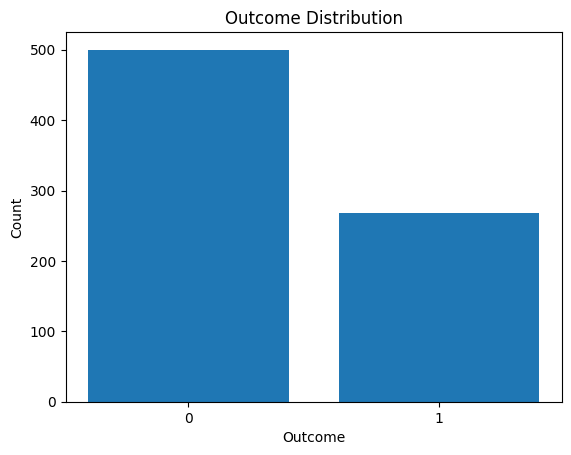

In [315]:
plt.bar(df['Outcome'].value_counts().index, df['Outcome'].value_counts())
plt.xticks([0, 1])
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Outcome Distribution')
plt.show()

In [316]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [317]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

In [318]:
col = numeric_features

In [319]:
for col in df.columns:
    if col != 'Outcome':
        df1[col + 'log'] = np.log(df[col] + 1)

In [320]:
df1

,Outcome,Pregnancieslog,Glucoselog,BloodPressurelog,SkinThicknesslog,Insulinlog,BMIlog,DiabetesPedigreeFunctionlog,Agelog
0,1,1.945910,5.003946,4.290459,3.583519,0.000000,3.543854,0.486738,3.931826
1,0,0.693147,4.454347,4.204693,3.401197,0.000000,3.317816,0.300845,3.465736
2,1,2.197225,5.214936,4.174387,0.000000,0.000000,3.190476,0.514021,3.496508
3,0,0.693147,4.499810,4.204693,3.178054,4.553877,3.370738,0.154436,3.091042
4,1,0.000000,4.927254,3.713572,3.583519,5.129899,3.786460,1.190279,3.526361
...,...,...,...,...,...,...,...,...,...
763,0,2.397895,4.624973,4.343805,3.891820,5.198497,3.523415,0.157858,4.158883
764,0,1.098612,4.812184,4.262680,3.332205,0.000000,3.632309,0.292670,3.332205
765,0,1.791759,4.804021,4.290459,3.178054,4.727388,3.303217,0.219136,3.433987
766,1,0.693147,4.844187,4.110874,0.000000,0.000000,3.437208,0.299364,3.871201


In [321]:
df1.head()

,Outcome,Pregnancieslog,Glucoselog,BloodPressurelog,SkinThicknesslog,Insulinlog,BMIlog,DiabetesPedigreeFunctionlog,Agelog
0,1,1.945910,5.003946,4.290459,3.583519,0.000000,3.543854,0.486738,3.931826
1,0,0.693147,4.454347,4.204693,3.401197,0.000000,3.317816,0.300845,3.465736
2,1,2.197225,5.214936,4.174387,0.000000,0.000000,3.190476,0.514021,3.496508
3,0,0.693147,4.499810,4.204693,3.178054,4.553877,3.370738,0.154436,3.091042
4,1,0.000000,4.927254,3.713572,3.583519,5.129899,3.786460,1.190279,3.526361


In [322]:
X = df1.drop('Outcome', axis=1)
y = df1['Outcome']

In [323]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25,random_state=42,stratify=y)

In [324]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [325]:
X_train

array([[-0.82049887,  0.12452188,  0.30924024, ...,  0.52381868,
        -0.69463695, -0.38935603],
       [ 1.64802112, -0.55298716,  0.24850936, ...,  0.32036141,
        -0.25070244,  1.27756377],
       [-0.82049887, -0.11752249,  0.00701728, ...,  0.33187883,
        -0.11813287, -0.86102945],
       ...,
       [-0.82049887, -0.34604877,  0.18444914, ...,  0.4761163 ,
        -0.86822633, -0.17741326],
       [ 1.30201691,  0.66635087,  0.42198362, ...,  0.26180554,
         2.06488897,  0.86245755],
       [ 0.38789912,  0.49554313, -0.03194654, ..., -0.044562  ,
        -0.59252499,  0.46961686]])

In [326]:
y_train

,Outcome
751,0
358,0
718,0
536,0
651,0
...,...
676,1
113,0
556,0
152,1


In [327]:
# Convert to tensors
X_train_tensor = torch.from_numpy(X_train).float()
X_test_tensor = torch.from_numpy(X_test).float()

y_train_tensor = torch.from_numpy(y_train.values).float().view(-1,1)
y_test_tensor = torch.from_numpy(y_test.values).float().view(-1,1)

In [328]:
X_test_tensor.shape[1]

8

In [329]:
X_train_tensor.shape[1]

8

In [330]:
y_train_tensor.shape

torch.Size([576, 1])

In [331]:
y_test_tensor.shape

torch.Size([192, 1])

# Question 02: [ Marks 20 ]

## Design a neural network using nn.Module.

### The model must contain:

Input layer

At least one hidden layer

Output layer

Suitable activation function



## Justify:

Number of hidden neurons

Choice of activation function

Print  the total number of trainable parameters.


## Write Answer 02:


In [332]:
import torch
import torch.nn as nn

In [333]:
class Model(nn.Module):

    def __init__(self, num_features):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(num_features, 3),
            nn.ReLU(),
            nn.Linear(3, 1),
            nn.Sigmoid()

        )

    def forward(self, features):
        out = self.network(features)
        return out

In [334]:
num_features = X_train_tensor.shape[1]

model = Model(num_features)

In [335]:
features

tensor([[0.5153],
        [0.7346],
        [0.2769],
        [0.7370],
        [0.0325],
        [0.3558],
        [0.2078],
        [0.5180]])

In [336]:
!pip install torchinfo

In [337]:
from torchinfo import summary

summary(model, input_size=(576,8))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [576, 1]                  --
├─Sequential: 1-1                        [576, 1]                  --
│    └─Linear: 2-1                       [576, 3]                  27
│    └─ReLU: 2-2                         [576, 3]                  --
│    └─Linear: 2-3                       [576, 1]                  4
│    └─Sigmoid: 2-4                      [576, 1]                  --
Total params: 31
Trainable params: 31
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.02
Input size (MB): 0.02
Forward/backward pass size (MB): 0.02
Params size (MB): 0.00
Estimated Total Size (MB): 0.04

The neural network contains an input layer, one hidden layer, and an output layer.
The input layer contains 8 neurons because the dataset has 8 features.
The hidden layer contains 3 neurons to keep the model simple and avoid overfitting.
ReLU activation is used in the hidden layer because it helps faster training and avoids vanishing gradients.
The output layer contains 1 neuron with a Sigmoid activation function to produce probabilities for binary classification.

# Question 03: [ Marks 10 ]

Choose an appropriate loss function.

Choose an optimizer.

<br>

Justify your choices based on:

Regression vs Classification

Nature of the dataset

## Write Answer 03:

In [338]:
import torch.nn as nn

loss_function = nn.BCELoss()

The problem is a binary classification task where the target variable (Outcome) has two possible values: 0 or 1.

Binary Cross Entropy Loss is appropriate because it measures the difference between the predicted probability (from the Sigmoid output) and the actual class label.

Since the output layer uses a Sigmoid activation function, the model produces values between 0 and 1, representing the probability of the positive class. BCELoss is specifically designed to work with such probability outputs.

In [339]:
#optimizer
optimizer = torch.optim.SGD( model.parameters(), lr = learning_rate )


# Question 04: [ Marks 15 ]

## Implement a full training loop:

Forward pass

Loss computation

Backward pass

Parameter update

Gradient reset

### Requirements:

Train for at least 100 epochs.

Print loss every 10 epochs.

Store training loss history(You can pick your own Data Structure).

Explain clearly what happens in each step of the pipeline.

## Write Answer 04:

In [340]:
learning_rate = 0.1
epochs = 100

In [341]:
#create model
model = Model(num_features)
#define loop
for epoch in range(epochs):

  #forward pass
  y_pred = model(X_train_tensor)
  #Loss calculate
  loss = loss_function(y_pred,y_train_tensor.reshape(-1,1))
  optimizer.zero_grad()  #zero gradient
  loss.backward()  #backward pass
  optimizer.step() #parameter update
  #print loss in each epoch
  if (epoch+1) % 10 == 0:
     print(f" {epoch+1} , Loss = {loss.item()} ")

 10 , Loss = 0.697928249835968 
 20 , Loss = 0.697928249835968 
 30 , Loss = 0.697928249835968 
 40 , Loss = 0.697928249835968 
 50 , Loss = 0.697928249835968 
 60 , Loss = 0.697928249835968 
 70 , Loss = 0.697928249835968 
 80 , Loss = 0.697928249835968 
 90 , Loss = 0.697928249835968 
 100 , Loss = 0.697928249835968 


# Question 05: [ Marks 10 ]

## Evaluate the model on test data.

## For regression:

Report MSE and MAE


## For classification:

Report Accuracy

Compare training vs testing performance.

State whether the model is underfitting or overfitting.

## Write Answer 05:

In [345]:
with torch.no_grad():
  y_pred = model.forward(X_test_tensor)
  y_pred= (y_pred > 0.5).float()
  accuracy = (y_pred == y_test_tensor).float().mean()
  print(f" Accuracy = {accuracy.item()}")

 Accuracy = 0.6510416865348816


# Question 06: [ Marks 20 ]

## Modify at least ONE of the following:

Learning rate

Number of hidden neurons

Number of epochs

### Train again and compare:

Convergence speed

Final performance

Explain how the change affected the model.

## Write Answer 06:

# Question 07: [ Marks 20 ]


# Training Analysis

Answer the following:

Why must gradients be reset every epoch?

What happens if learning rate is too high?

What happens if learning rate is too small?

Why do we define layers inside the constructor (__init__) and not inside forward()?


## Write Answer 07: